# 04 – KMeans Exploration (non supervisé)

**Entrée** : `data/processed/attrition_with_time_features.csv` (4410 lignes)

**Méthode** : KMeans avec k optimal sélectionné automatiquement via silhouette maximale (k=2 à 10)

**Objectif** : Segmentation exploratoire des employés par clustering

> Non supervisé uniquement. Corrélation != causalité.

## 1. Imports et configuration

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Configuration
RANDOM_STATE = 42
TARGET = 'Attrition'
EXPORT_DIR = '../data/processed'
FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 2. Chargement des données

In [17]:
df = pd.read_csv(f'{EXPORT_DIR}/attrition_with_time_features.csv')
print(f'Shape : {df.shape}')
print(f'NaN total : {df.isna().sum().sum()}')
print(f'\nDistribution Attrition :')
print(df[TARGET].value_counts())

Shape : (4410, 51)
NaN total : 0

Distribution Attrition :
Attrition
0    3699
1     711
Name: count, dtype: int64


## 3. Analyse exploratoire (EDA)

Avant de passer au clustering, on explore le dataset pour comprendre la distribution des variables et identifier des tendances.

### 3.1 Statistiques descriptives

In [18]:
# Résumé statistique des variables numériques
print(f'Nombre de features : {df.shape[1]}')
print(f'Nombre d\'employés : {df.shape[0]}')
print(f'\nTypes de colonnes :')
print(df.dtypes.value_counts())
print(f'\n=== describe() ===')
df.describe().T

Nombre de features : 51
Nombre d'employés : 4410

Types de colonnes :
int64      37
float64    14
Name: count, dtype: int64

=== describe() ===


,count,mean,std,min,25%,50%,75%,max
Age,4410.0,36.923810,9.133301,18.000000,30.000000,36.000000,43.000000,60.000000
Attrition,4410.0,0.161224,0.367780,0.000000,0.000000,0.000000,0.000000,1.000000
DistanceFromHome,4410.0,9.192517,8.105026,1.000000,2.000000,7.000000,14.000000,29.000000
Education,4410.0,2.912925,1.023933,1.000000,2.000000,3.000000,4.000000,5.000000
EmployeeID,4410.0,2205.500000,1273.201673,1.000000,1103.250000,2205.500000,3307.750000,4410.000000
JobLevel,4410.0,2.063946,1.106689,1.000000,1.000000,2.000000,3.000000,5.000000
MonthlyIncome,4410.0,65029.312925,47068.888559,10090.000000,29110.000000,49190.000000,83800.000000,199990.000000
NumCompaniesWorked,4410.0,2.691837,2.493912,0.000000,1.000000,2.000000,4.000000,9.000000
PercentSalaryHike,4410.0,15.209524,3.659108,11.000000,12.000000,14.000000,18.000000,25.000000
StockOptionLevel,4410.0,0.793878,0.851883,0.000000,0.000000,1.000000,1.000000,3.000000


### 3.2 Distribution de la target (Attrition)

No attrition : 3699 (83.9%)
Attrition    : 711 (16.1%)


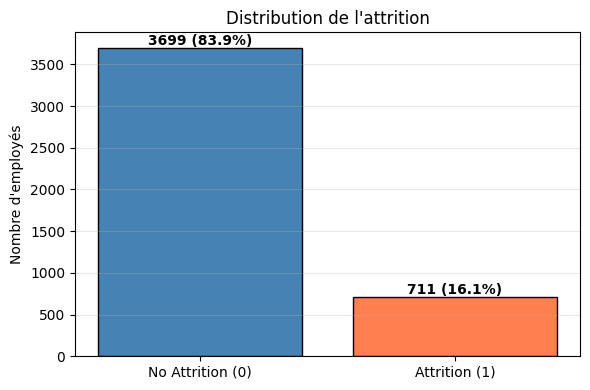

In [19]:
# Taux d'attrition global
attrition_counts = df[TARGET].value_counts()
attrition_pct = df[TARGET].value_counts(normalize=True)

print(f'No attrition : {attrition_counts[0]} ({attrition_pct[0]:.1%})')
print(f'Attrition    : {attrition_counts[1]} ({attrition_pct[1]:.1%})')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Attrition (0)', 'Attrition (1)'], attrition_counts.values,
              color=['steelblue', 'coral'], edgecolor='black')
for bar, val in zip(bars, attrition_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val} ({val/len(df):.1%})', ha='center', fontweight='bold')
ax.set_ylabel('Nombre d\'employés')
ax.set_title('Distribution de l\'attrition')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 Distributions des features numériques clés

On affiche les histogrammes des principales variables numériques, colorés par attrition.

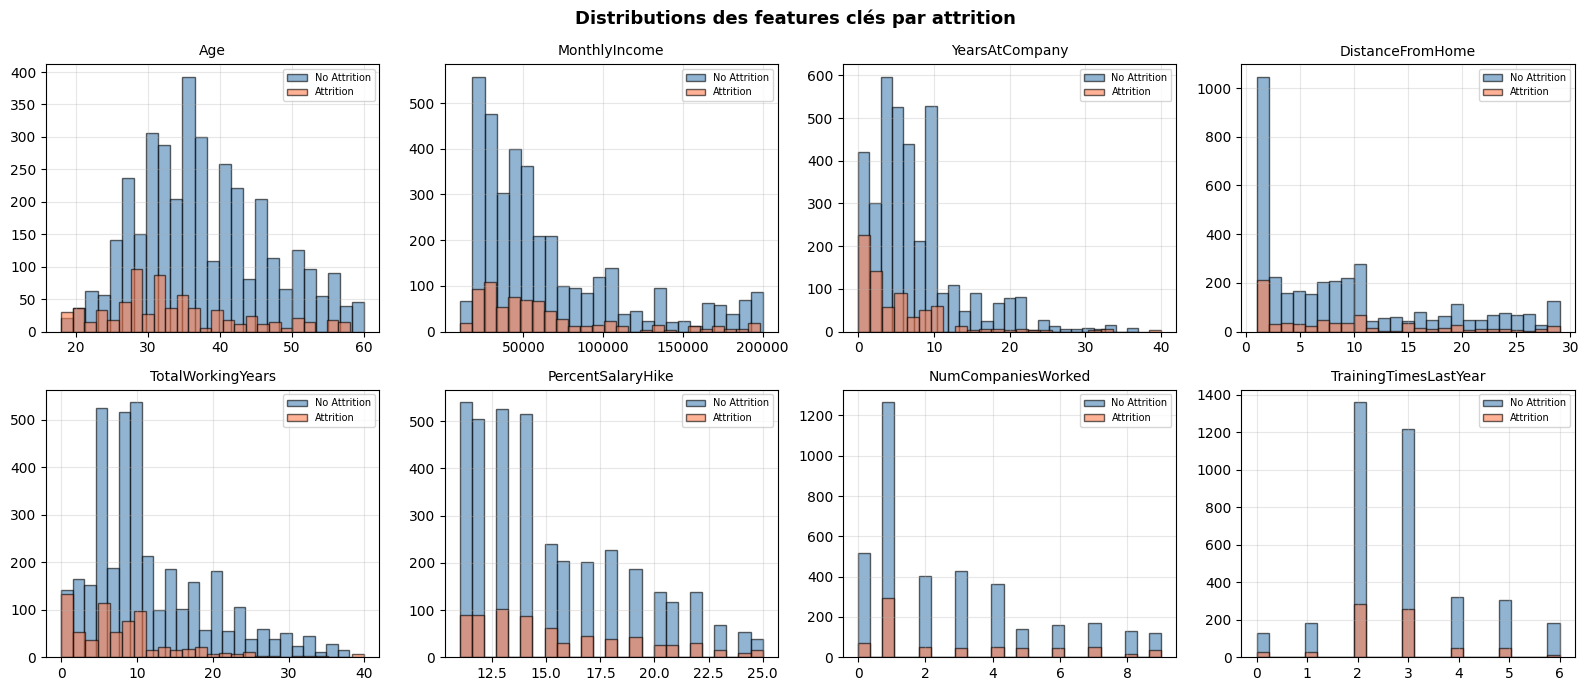

In [20]:
# Features clés à visualiser
key_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome',
                'TotalWorkingYears', 'PercentSalaryHike', 'NumCompaniesWorked',
                'TrainingTimesLastYear']
key_features = [f for f in key_features if f in df.columns]

n_cols = 4
n_rows = (len(key_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for idx, feat in enumerate(key_features):
    ax = axes[idx]
    ax.hist(df[df[TARGET] == 0][feat].dropna(), bins=25, alpha=0.6,
            label='No Attrition', color='steelblue', edgecolor='black')
    ax.hist(df[df[TARGET] == 1][feat].dropna(), bins=25, alpha=0.6,
            label='Attrition', color='coral', edgecolor='black')
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

for idx in range(len(key_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distributions des features clés par attrition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Corrélations avec Attrition

On calcule les corrélations de Pearson entre chaque feature numérique et la variable `Attrition`.

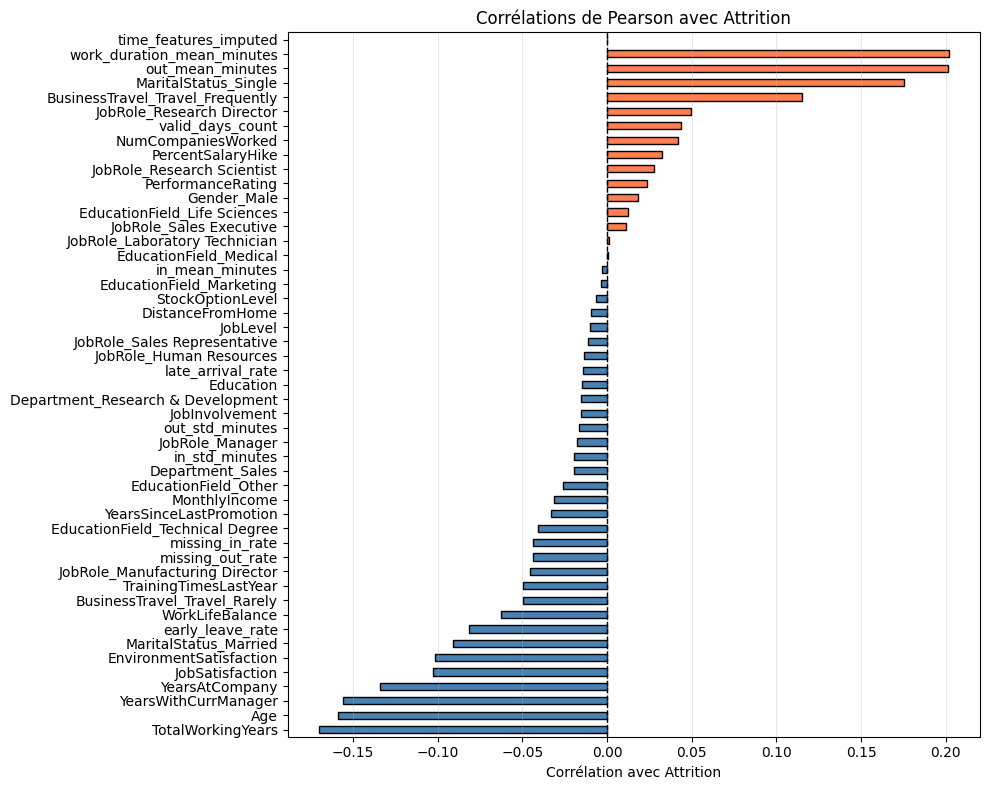

In [21]:
# Colonnes numériques (sans EmployeeID et Attrition)
numerical_cols = [c for c in df.select_dtypes(include='number').columns
                  if c not in ['EmployeeID', TARGET]]

correlations = df[numerical_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

# Top corrélations positives et négatives
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['coral' if x > 0 else 'steelblue' for x in correlations.values]
correlations.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_xlabel('Corrélation avec Attrition')
ax.set_title('Corrélations de Pearson avec Attrition')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.5 Matrice de corrélation (top features)

Heatmap des corrélations entre les 15 features les plus corrélées à l'attrition.

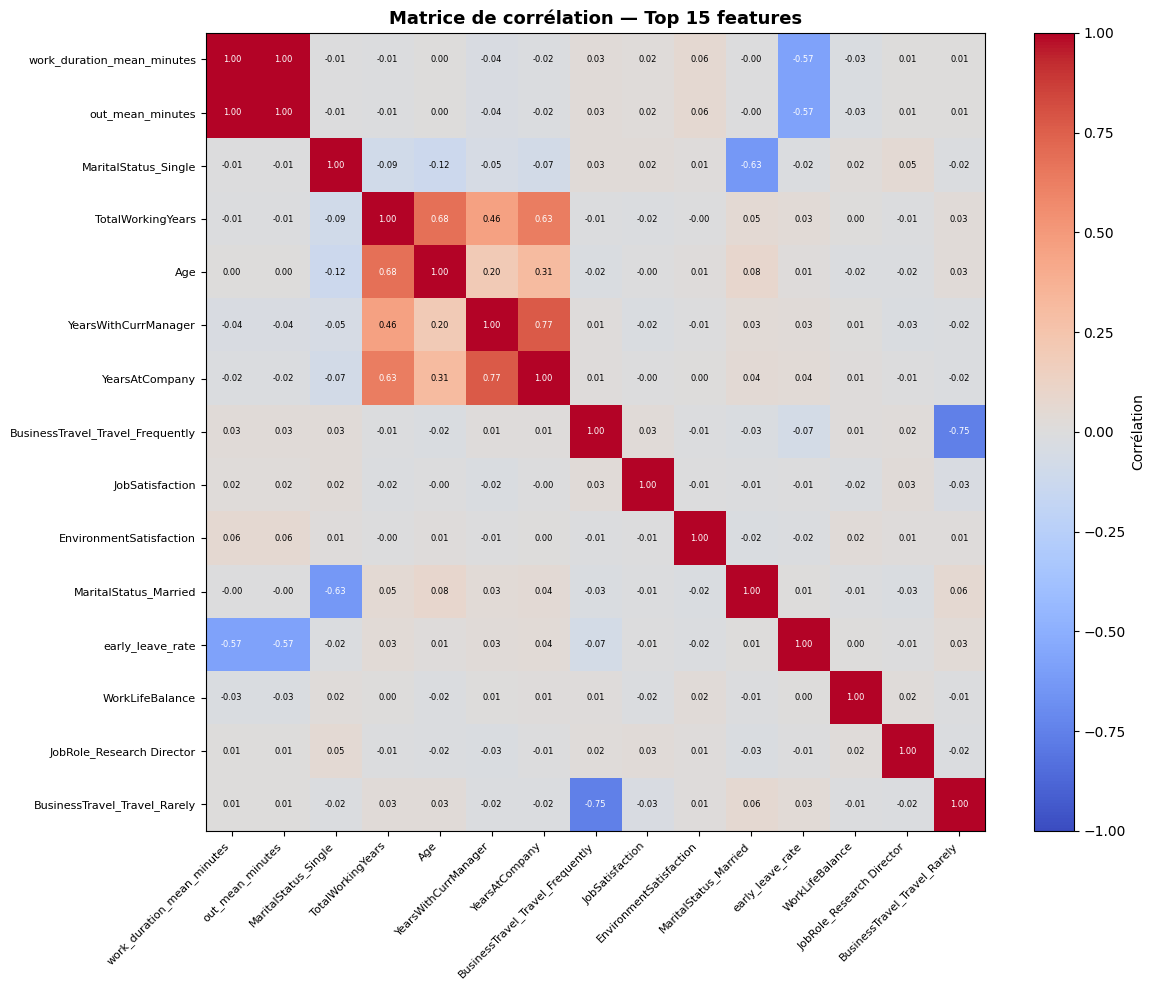

In [22]:
# Top 15 features les plus corrélées (en valeur absolue)
top15 = correlations.abs().nlargest(15).index.tolist()
corr_matrix = df[top15].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(top15)))
ax.set_yticks(range(len(top15)))
ax.set_xticklabels(top15, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(top15, fontsize=8)

# Annotations
for i in range(len(top15)):
    for j in range(len(top15)):
        ax.text(j, i, f'{corr_matrix.values[i, j]:.2f}',
                ha='center', va='center', fontsize=6,
                color='white' if abs(corr_matrix.values[i, j]) > 0.5 else 'black')

fig.colorbar(im, label='Corrélation')
ax.set_title('Matrice de corrélation — Top 15 features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Sélection des features et standardisation

On exclut `EmployeeID` (identifiant) et `Attrition` (target) du clustering.

In [23]:
exclude = ['EmployeeID', TARGET, 'cluster']
feature_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in exclude]
X = df[feature_cols].copy()

print(f'Features retenues : {len(feature_cols)}')
print(f'NaN dans X : {X.isnull().sum().sum()}')

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'X_scaled shape : {X_scaled.shape}')

Features retenues : 49
NaN dans X : 0
X_scaled shape : (4410, 49)


## 5. Sélection automatique de k

On teste k de 2 à 10 et on sélectionne k_best = argmax(silhouette).

In [24]:
K_RANGE = range(2, 11)
k_scores = []

for k in K_RANGE:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    k_scores.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': round(sil, 4)
    })

k_search_df = pd.DataFrame(k_scores)
k_best = int(k_search_df.loc[k_search_df['silhouette'].idxmax(), 'k'])
best_score = k_search_df.loc[k_search_df['silhouette'].idxmax(), 'silhouette']

print('=== Scores par k ===')
print(k_search_df.to_string(index=False))
print(f'\n=> k_best = {k_best} (silhouette = {best_score:.4f})')

=== Scores par k ===
 k       inertia  silhouette
 2 201224.996545      0.0481
 3 194867.369351      0.0512
 4 188657.190380      0.0510
 5 184962.637351      0.0456
 6 181622.844037      0.0492
 7 177607.081637      0.0531
 8 175528.383429      0.0542
 9 172759.182684      0.0526
10 171792.704916      0.0454

=> k_best = 8 (silhouette = 0.0542)


### Visualisation : Silhouette vs k et Elbow

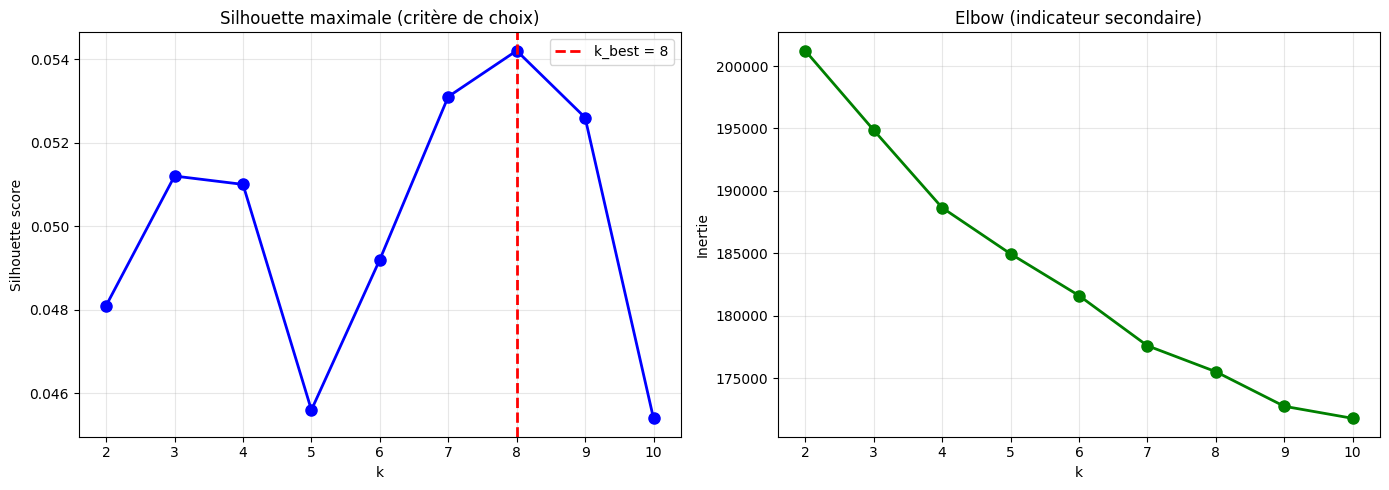

Figure sauvegardee : ..\reports\figures\kmeans_k_selection.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Silhouette ---
ax = axes[0]
ax.plot(k_search_df['k'], k_search_df['silhouette'], 'bo-',
        linewidth=2, markersize=8)
ax.axvline(x=k_best, color='red', linestyle='--', linewidth=2,
           label=f'k_best = {k_best}')
ax.set_xlabel('k')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette maximale (critère de choix)')
ax.set_xticks(list(K_RANGE))
ax.legend()
ax.grid(alpha=0.3)

# --- Elbow ---
ax = axes[1]
ax.plot(k_search_df['k'], k_search_df['inertia'], 'go-',
        linewidth=2, markersize=8)
ax.set_xlabel('k')
ax.set_ylabel('Inertie')
ax.set_title('Elbow (indicateur secondaire)')
ax.set_xticks(list(K_RANGE))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Figure sauvegardee : {FIG_DIR / "kmeans_k_selection.png"}')

## 6. Clustering final (k = k_best)

In [26]:
kmeans = KMeans(n_clusters=k_best, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(X_scaled)

inertia = kmeans.inertia_
silhouette = silhouette_score(X_scaled, clusters)

print(f'k              : {k_best}')
print(f'Inertie        : {inertia:.2f}')
print(f'Silhouette     : {silhouette:.4f}')
print(f'Tailles        : {np.bincount(clusters).tolist()}')

# Ajouter la colonne cluster au dataframe
df['cluster'] = clusters

k              : 8
Inertie        : 175528.38
Silhouette     : 0.0542
Tailles        : [1030, 1127, 240, 237, 555, 464, 411, 346]


## 7. Visualisations

### PCA 2D coloré par cluster

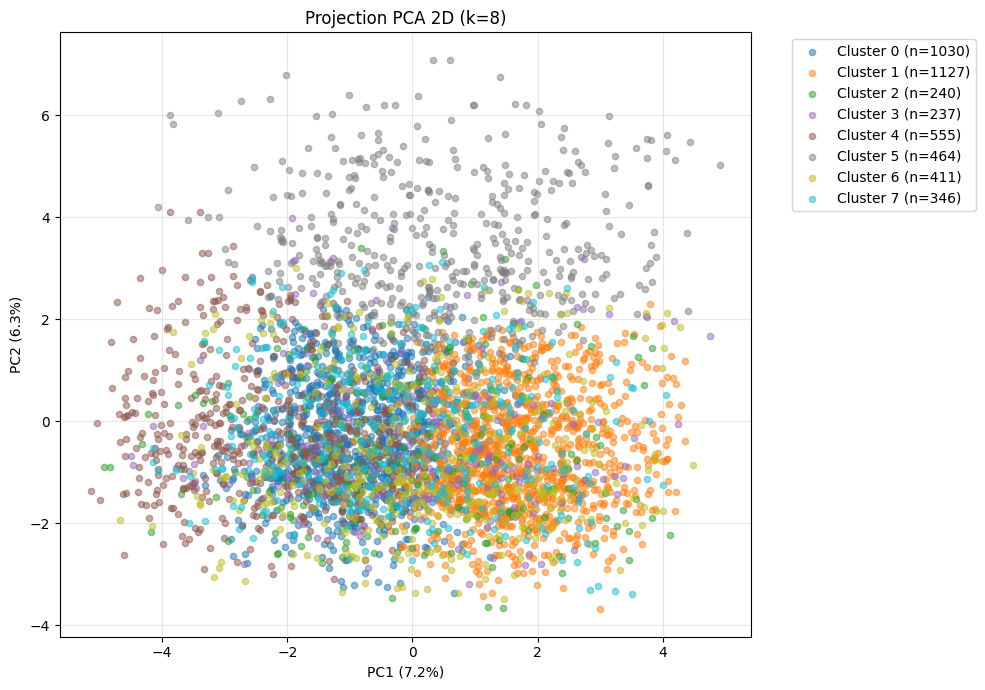

Figure sauvegardee : ..\reports\figures\kmeans_pca.png


In [27]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.cm.get_cmap('tab10', k_best)
for c in range(k_best):
    mask = clusters == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               alpha=0.5, s=20, color=cmap(c),
               label=f'Cluster {c} (n={mask.sum()})')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'Projection PCA 2D (k={k_best})')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_pca.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Figure sauvegardee : {FIG_DIR / "kmeans_pca.png"}')

### Taux d'attrition par cluster (observation)

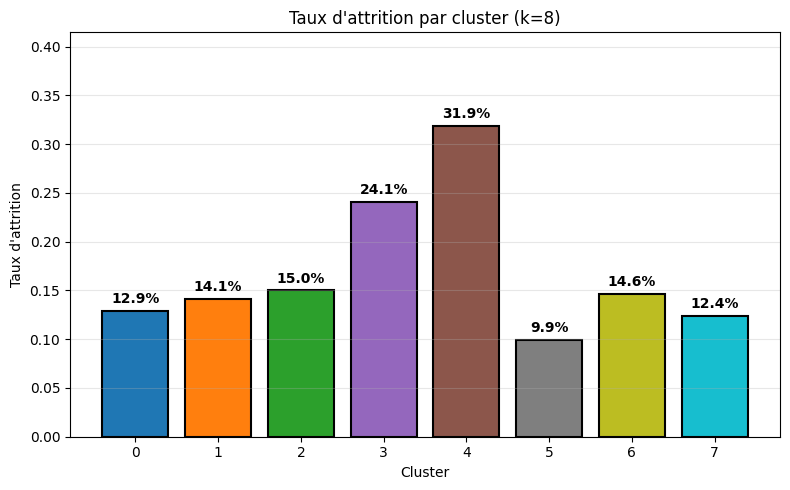

Figure sauvegardee : ..\reports\figures\kmeans_attrition.png


In [28]:
attrition_by_cluster = df.groupby('cluster')[TARGET].mean()

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.get_cmap('tab10', k_best)
colors = [cmap(i) for i in range(k_best)]

bars = ax.bar(range(k_best), attrition_by_cluster.values,
              color=colors, edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, attrition_by_cluster.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.1%}', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Cluster')
ax.set_ylabel('Taux d\'attrition')
ax.set_title(f'Taux d\'attrition par cluster (k={k_best})')
ax.set_xticks(range(k_best))
ax.set_ylim(0, max(attrition_by_cluster.values) * 1.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_attrition.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Figure sauvegardee : {FIG_DIR / "kmeans_attrition.png"}')

## 8. Exports

In [29]:
# Export CSV
df.to_csv(f'{EXPORT_DIR}/kmeans_attrition_clusters.csv', index=False)
print(f'CSV : {EXPORT_DIR}/kmeans_attrition_clusters.csv ({df.shape})')

# Export JSON (metriques uniquement)
metrics = {
    'k_best': int(k_best),
    'silhouette_score': round(float(silhouette), 4),
    'inertia': round(float(inertia), 2),
    'cluster_sizes': np.bincount(clusters).tolist()
}

with open(f'{EXPORT_DIR}/kmeans_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'JSON : {EXPORT_DIR}/kmeans_metrics.json')
print(json.dumps(metrics, indent=2))

CSV : ../data/processed/kmeans_attrition_clusters.csv ((4410, 52))
JSON : ../data/processed/kmeans_metrics.json
{
  "k_best": 8,
  "silhouette_score": 0.0542,
  "inertia": 175528.38,
  "cluster_sizes": [
    1030,
    1127,
    240,
    237,
    555,
    464,
    411,
    346
  ]
}


## 9. Validation finale

In [30]:
print('Shape :', df.shape)
print('NaN total :', df.isna().sum().sum())
print('k_best :', k_best)
print('Silhouette :', round(best_score, 4))

Shape : (4410, 52)
NaN total : 0
k_best : 8
Silhouette : 0.0542
